<a href="https://colab.research.google.com/github/contactyuvrajchand-droid/machine_learning_lab/blob/main/Week_10_IMDB_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CN7030 — Big Data Technologies
## Assessment Lab 10: IMDB Sentiment Analysis with PySpark Linear SVM



---
## Section 1 — Pipeline Architecture

1. Mount Google Drive and locate `aclImdb_v1.tar.gz`.
2. Extract the archive into Colab's temporary local storage.
3. Load `train/pos`, `train/neg`, `test/pos`, and `test/neg` as Spark DataFrames.
4. Encode negative sentiment as `0.0` and positive sentiment as `1.0`.
5. Clean the text, tokenise it, remove stop words, and construct TF–IDF vectors.
6. Fit `LinearSVC` only on the official training split.
7. Predict the official test split and calculate classification metrics.

Fitting the IDF stage and SVM only on training data prevents information from the
test set leaking into model training.

---
## Section 2 — Environment Setup

Install PySpark and import the libraries required by the notebook. This cell only
needs to be run once in each new Colab session.

In [ ]:
# Install PySpark in Google Colab.
!pip install -q pyspark

# Standard Python libraries.
import os
import tarfile
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PySpark libraries.
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, length, lit, lower, regexp_replace, size,
    split, sum as spark_sum, trim, when
)
from pyspark.ml import Pipeline
from pyspark.ml.classification import LinearSVC
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, HashingTF, IDF

# Plot style.
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
})

print("All imports completed successfully.")

All imports completed successfully.


---
## Section 3 — Initialise the Spark Session

Spark runs in local mode in Colab, while the DataFrame and ML pipeline APIs remain
the same as those used on a distributed Spark cluster.

In [ ]:
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("CN7030_Lab10_IMDB_LinearSVM")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print(f"Spark version: {spark.version}")
print(f"Master: {spark.sparkContext.master}")
print(f"Application: {spark.sparkContext.appName}")

Spark version: 4.0.3
Master: local[*]
Application: CN7030_Lab10_IMDB_LinearSVM


---
## Section 4 — Mount Google Drive and Extract the Dataset

The archive is read from `MyDrive/Colab Notebooks/lab10`. Extraction is performed
in `/content/imdb_data`, which is faster for Spark than repeatedly reading many
small review files directly from Google Drive.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

# Exact Google Drive location of the dataset archive.
archive_path = "/content/drive/MyDrive/Colab Notebooks/lab10/aclImdb_v1.tar.gz"

if not os.path.isfile(archive_path):
    raise FileNotFoundError(
        "aclImdb_v1.tar.gz was not found. Confirm that it is inside "
        "MyDrive/Colab Notebooks/lab10."
    )

extract_root = "/content/imdb_data"
dataset_root = os.path.join(extract_root, "aclImdb")
required_folders = [
    os.path.join(dataset_root, "train", "pos"),
    os.path.join(dataset_root, "train", "neg"),
    os.path.join(dataset_root, "test", "pos"),
    os.path.join(dataset_root, "test", "neg"),
]

if not all(os.path.isdir(folder) for folder in required_folders):
    os.makedirs(extract_root, exist_ok=True)
    print("Extracting IMDB dataset...")
    with tarfile.open(archive_path, "r:gz") as archive:
        # filter='data' is supported by current Colab Python versions.
        # The fallback keeps the notebook compatible with older runtimes.
        try:
            archive.extractall(extract_root, filter="data")
        except TypeError:
            archive.extractall(extract_root)
else:
    print("Dataset is already extracted; extraction skipped.")

if not all(os.path.isdir(folder) for folder in required_folders):
    raise RuntimeError("Extraction completed, but the expected IMDB folders were not found.")

print(f"Archive: {archive_path}")
print(f"Dataset root: {dataset_root}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset is already extracted; extraction skipped.
Archive: /content/drive/MyDrive/Colab Notebooks/lab10/aclImdb_v1.tar.gz
Dataset root: /content/imdb_data/aclImdb


---
## Section 5 — Load the IMDB Reviews into Spark DataFrames

IMDB stores each review in a separate `.txt` file. Spark's whole-text option loads
one complete file per DataFrame row. Positive reviews receive label `1.0`, while
negative reviews receive label `0.0`.

In [ ]:
def load_imdb_split(split_name):
    # Load one official IMDB split (train or test) as a Spark DataFrame.
    positive_path = os.path.join(dataset_root, split_name, "pos", "*.txt")
    negative_path = os.path.join(dataset_root, split_name, "neg", "*.txt")

    positive_df = (
        spark.read.text(positive_path, wholetext=True)
        .withColumnRenamed("value", "review")
        .withColumn("label", lit(1.0))
        .withColumn("sentiment", lit("positive"))
    )

    negative_df = (
        spark.read.text(negative_path, wholetext=True)
        .withColumnRenamed("value", "review")
        .withColumn("label", lit(0.0))
        .withColumn("sentiment", lit("negative"))
    )

    return positive_df.unionByName(negative_df)


train_raw = load_imdb_split("train").cache()
test_raw = load_imdb_split("test").cache()

train_count = train_raw.count()
test_count = test_raw.count()

print("Training schema")
train_raw.printSchema()
print(f"Training reviews: {train_count:,}")
print(f"Testing reviews:  {test_count:,}")

if train_count != 25000 or test_count != 25000:
    print("Warning: the official dataset normally contains 25,000 labelled reviews per split.")

print("\nSample reviews")
train_raw.select("review", "sentiment", "label").show(4, truncate=100)

Training schema
root
 |-- review: string (nullable = true)
 |-- label: double (nullable = false)
 |-- sentiment: string (nullable = false)

Training reviews: 25,000
Testing reviews:  25,000

Sample reviews
+----------------------------------------------------------------------------------------------------+---------+-----+
|                                                                                              review|sentiment|label|
+----------------------------------------------------------------------------------------------------+---------+-----+
|Match 1: Tag Team Table Match Bubba Ray and Spike Dudley vs Eddie Guerrero and Chris Benoit Bubba...| positive|  1.0|
|**Attention Spoilers**<br /><br />First of all, let me say that Rob Roy is one of the best films ...| positive|  1.0|
|Titanic directed by James Cameron presents a fictional love story on the historical setting of th...| positive|  1.0|
|By now you've probably heard a bit about the new Disney dub of Miyazaki's class

---
## Section 6 — Exploratory Data Analysis

Class distributions are checked separately for training and testing data. Because
IMDB is balanced, accuracy is meaningful, but precision, recall, and F1-score are
still reported to show the model's behaviour for positive reviews.

sentiment  label  count split
 negative    0.0  12500  Test
 positive    1.0  12500  Test
 negative    0.0  12500 Train
 positive    1.0  12500 Train


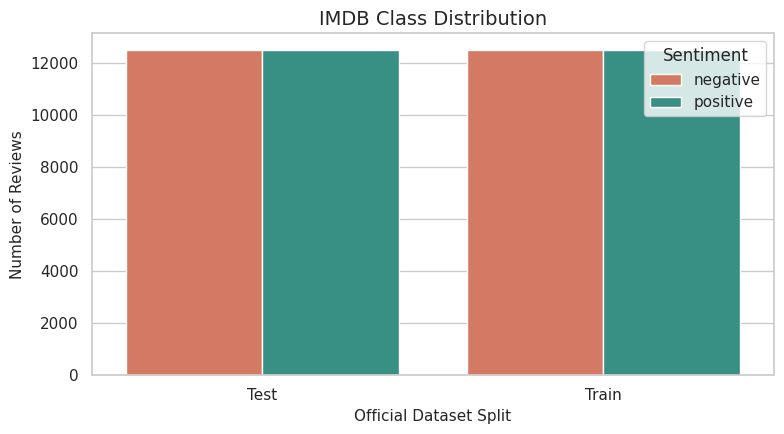


Training review word-count summary
+-------+-----------------+
|summary|word_count       |
+-------+-----------------+
|count  |25000            |
|mean   |233.77856        |
|stddev |173.7212617021792|
|min    |10               |
|max    |2470             |
+-------+-----------------+



In [ ]:
train_distribution = (
    train_raw.groupBy("sentiment", "label")
    .count()
    .withColumn("split", lit("Train"))
)

test_distribution = (
    test_raw.groupBy("sentiment", "label")
    .count()
    .withColumn("split", lit("Test"))
)

distribution_pd = (
    train_distribution.unionByName(test_distribution)
    .orderBy("split", "label")
    .toPandas()
)

print(distribution_pd.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=distribution_pd,
    x="split",
    y="count",
    hue="sentiment",
    palette={"negative": "#e76f51", "positive": "#2a9d8f"},
    ax=ax,
)
ax.set_title("IMDB Class Distribution")
ax.set_xlabel("Official Dataset Split")
ax.set_ylabel("Number of Reviews")
ax.legend(title="Sentiment")
plt.tight_layout()
plt.show()

# Distributed review-length summary for the training split.
length_summary = (
    train_raw.withColumn("word_count", size(split(trim(col("review")), r"\s+")))
    .select("word_count")
    .summary("count", "mean", "stddev", "min", "max")
)
print("\nTraining review word-count summary")
length_summary.show(truncate=False)

---
## Section 7 — Text Cleaning

The cleaning function:

- converts review text to lower case;
- removes HTML tags such as `<br />`;
- removes digits and punctuation;
- replaces repeated whitespace with a single space; and
- drops empty reviews.

Tokenisation and stop-word removal are applied later inside the fitted ML pipeline.

In [ ]:
def clean_reviews(dataframe):
    return (
        dataframe
        .withColumn("clean_review", lower(col("review")))
        .withColumn("clean_review", regexp_replace(col("clean_review"), r"<[^>]+>", " "))
        .withColumn("clean_review", regexp_replace(col("clean_review"), r"[^a-z\s]", " "))
        .withColumn("clean_review", regexp_replace(col("clean_review"), r"\s+", " "))
        .withColumn("clean_review", trim(col("clean_review")))
        .filter(length(col("clean_review")) > 0)
        .select("review", "clean_review", "sentiment", "label")
    )


train_df = clean_reviews(train_raw).cache()
test_df = clean_reviews(test_raw).cache()

cleaned_train_count = train_df.count()
cleaned_test_count = test_df.count()

print(f"Clean training reviews: {cleaned_train_count:,}")
print(f"Clean testing reviews:  {cleaned_test_count:,}")
print("\nCleaned examples")
train_df.select("clean_review", "sentiment", "label").show(4, truncate=100)

Clean training reviews: 25,000
Clean testing reviews:  25,000

Cleaned examples
+----------------------------------------------------------------------------------------------------+---------+-----+
|                                                                                        clean_review|sentiment|label|
+----------------------------------------------------------------------------------------------------+---------+-----+
|match tag team table match bubba ray and spike dudley vs eddie guerrero and chris benoit bubba ra...| positive|  1.0|
|attention spoilers first of all let me say that rob roy is one of the best films of the s it was ...| positive|  1.0|
|titanic directed by james cameron presents a fictional love story on the historical setting of th...| positive|  1.0|
|by now you ve probably heard a bit about the new disney dub of miyazaki s classic film laputa cas...| positive|  1.0|
+--------------------------------------------------------------------------------------

---
## Section 8 — Use the Official Train/Test Split

No random split is required because IMDB already provides 25,000 training and
25,000 testing reviews. The official test data remains unseen during TF–IDF fitting
and SVM training.

   Split  Reviews Percentage
Training    25000      50.0%
 Testing    25000      50.0%


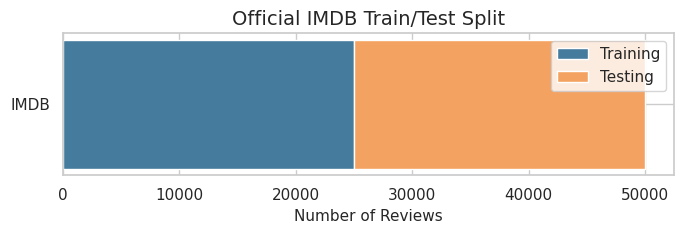

In [ ]:
split_check = pd.DataFrame({
    "Split": ["Training", "Testing"],
    "Reviews": [cleaned_train_count, cleaned_test_count],
})
split_check["Percentage"] = (
    split_check["Reviews"] / split_check["Reviews"].sum() * 100
)

print(split_check.to_string(index=False, formatters={"Percentage": "{:.1f}%".format}))

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.barh(["IMDB"], [cleaned_train_count], color="#457b9d", label="Training")
ax.barh(
    ["IMDB"], [cleaned_test_count], left=[cleaned_train_count],
    color="#f4a261", label="Testing"
)
ax.set_title("Official IMDB Train/Test Split")
ax.set_xlabel("Number of Reviews")
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 9 — TF–IDF Feature Engineering

- `RegexTokenizer` separates each cleaned review into word tokens.
- `StopWordsRemover` removes frequent English words with little sentiment value.
- `HashingTF` converts tokens to sparse term-frequency vectors.
- `IDF` reduces the influence of terms that appear in many reviews.

`65,536` hashed features provide a practical balance between vocabulary capacity
and Colab memory/training time.

In [ ]:
tokenizer = RegexTokenizer(
    inputCol="clean_review",
    outputCol="tokens",
    pattern=r"\W+",
    minTokenLength=2,
    toLowercase=True,
)

stopword_remover = StopWordsRemover(
    inputCol="tokens",
    outputCol="filtered_tokens",
    caseSensitive=False,
)

hashing_tf = HashingTF(
    inputCol="filtered_tokens",
    outputCol="term_frequency",
    numFeatures=2**16,
    binary=False,
)

idf = IDF(
    inputCol="term_frequency",
    outputCol="features",
    minDocFreq=2,
)

print("TF-IDF stages configured.")
print(f"Feature dimensions: {hashing_tf.getNumFeatures():,}")

TF-IDF stages configured.
Feature dimensions: 65,536


---
## Section 10 — Train the Linear SVM Pipeline

`LinearSVC` is suitable for high-dimensional sparse text features. The complete
pipeline is fitted once on the training DataFrame, ensuring that IDF weights are
also learned from training reviews only.

In [ ]:
linear_svm = LinearSVC(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    rawPredictionCol="rawPrediction",
    maxIter=30,
    regParam=0.1,
    tol=1e-6,
)

svm_pipeline = Pipeline(stages=[
    tokenizer,
    stopword_remover,
    hashing_tf,
    idf,
    linear_svm,
])

print("Training Linear SVM...")
start_time = time.time()
svm_model = svm_pipeline.fit(train_df)
training_time = time.time() - start_time

predictions = svm_model.transform(test_df).cache()
prediction_count = predictions.count()

print(f"Training completed in {training_time:.1f} seconds.")
print(f"Predictions generated: {prediction_count:,}")

print("\nEvidence of tokens and sparse TF-IDF features")
predictions.select(
    "clean_review", "tokens", "filtered_tokens", "features"
).show(3, truncate=80)

Training Linear SVM...
Training completed in 553.3 seconds.
Predictions generated: 25,000

Evidence of tokens and sparse TF-IDF features
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                    clean_review|                                                                          tokens|                                                                 filtered_tokens|                                                                        features|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+------------------------------------------------

---
## Section 11 — Evaluate Accuracy, Precision, Recall, and F1-Score

Positive sentiment (`1.0`) is treated as the positive class.

- **Accuracy**: proportion of all correctly classified reviews.
- **Precision**: proportion of predicted-positive reviews that are truly positive.
- **Recall**: proportion of truly positive reviews detected by the model.
- **F1-score**: harmonic mean of precision and recall.
- **AUC-ROC**: ranking quality across different decision thresholds.

Linear SVM evaluation results
   Metric  Score
 Accuracy 0.8471
Precision 0.8551
   Recall 0.8358
 F1-score 0.8453
  AUC-ROC 0.9148

Training time: 553.3 seconds


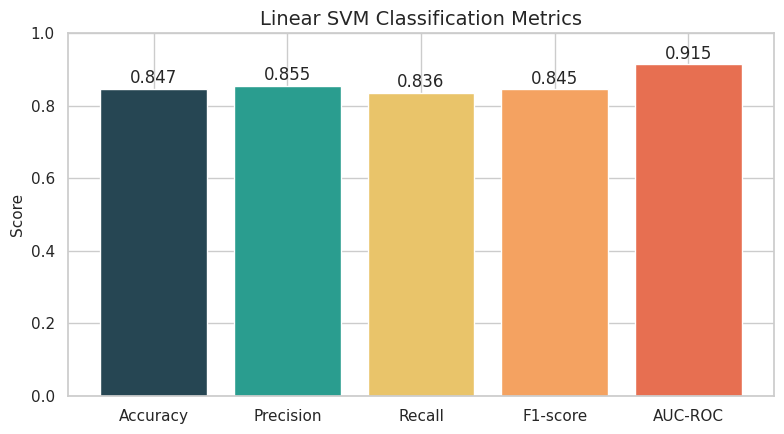

In [ ]:
# Calculate the four confusion-matrix counts in one distributed aggregation.
counts = predictions.agg(
    count(lit(1)).alias("total"),
    spark_sum(when(col("prediction") == col("label"), 1).otherwise(0)).alias("correct"),
    spark_sum(when((col("label") == 1.0) & (col("prediction") == 1.0), 1).otherwise(0)).alias("tp"),
    spark_sum(when((col("label") == 0.0) & (col("prediction") == 1.0), 1).otherwise(0)).alias("fp"),
    spark_sum(when((col("label") == 1.0) & (col("prediction") == 0.0), 1).otherwise(0)).alias("fn"),
    spark_sum(when((col("label") == 0.0) & (col("prediction") == 0.0), 1).otherwise(0)).alias("tn"),
).first()

total = int(counts["total"])
correct = int(counts["correct"])
tp = int(counts["tp"])
fp = int(counts["fp"])
fn = int(counts["fn"])
tn = int(counts["tn"])

accuracy = correct / total if total else 0.0
precision = tp / (tp + fp) if (tp + fp) else 0.0
recall = tp / (tp + fn) if (tp + fn) else 0.0
f1_score = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) else 0.0
)

auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC",
)
auc_roc = auc_evaluator.evaluate(predictions)

metrics_pd = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC"],
    "Score": [accuracy, precision, recall, f1_score, auc_roc],
})

print("Linear SVM evaluation results")
print(metrics_pd.to_string(index=False, formatters={"Score": "{:.4f}".format}))
print(f"\nTraining time: {training_time:.1f} seconds")

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(
    metrics_pd["Metric"], metrics_pd["Score"],
    color=["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]
)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Linear SVM Classification Metrics")
for bar, score in zip(bars, metrics_pd["Score"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.015,
        f"{score:.3f}",
        ha="center",
    )
plt.tight_layout()
plt.show()

---
## Section 12 — Confusion Matrix

The confusion matrix shows the exact numbers of true negatives, false positives,
false negatives, and true positives. This makes it possible to see whether the
classifier makes more errors on positive or negative reviews.

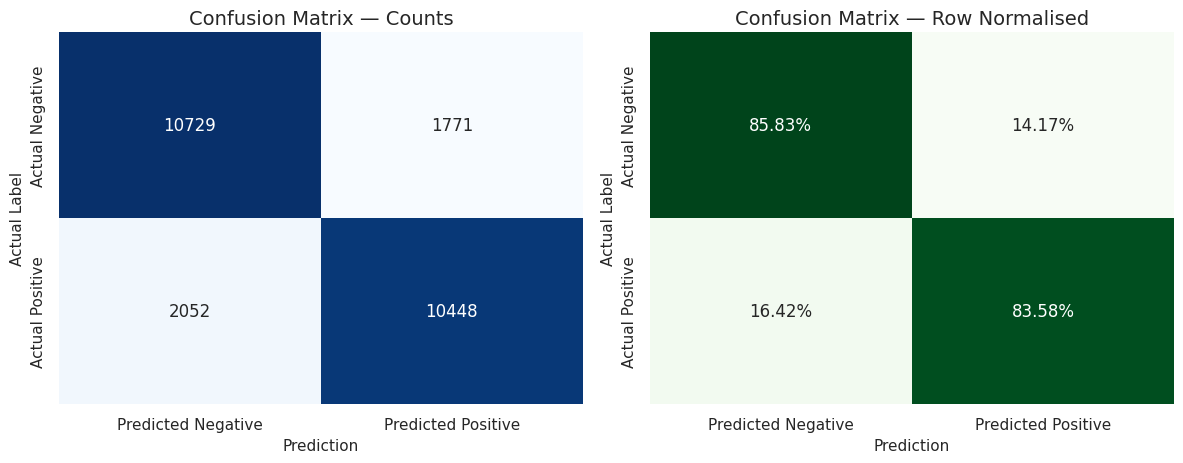

True negatives:  10,729
False positives: 1,771
False negatives: 2,052
True positives:  10,448


In [ ]:
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp],
])

confusion_matrix_normalised = (
    confusion_matrix / confusion_matrix.sum(axis=1, keepdims=True)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted Negative", "Predicted Positive"],
    yticklabels=["Actual Negative", "Actual Positive"],
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix — Counts")
axes[0].set_xlabel("Prediction")
axes[0].set_ylabel("Actual Label")

sns.heatmap(
    confusion_matrix_normalised,
    annot=True,
    fmt=".2%",
    cmap="Greens",
    cbar=False,
    xticklabels=["Predicted Negative", "Predicted Positive"],
    yticklabels=["Actual Negative", "Actual Positive"],
    ax=axes[1],
)
axes[1].set_title("Confusion Matrix — Row Normalised")
axes[1].set_xlabel("Prediction")
axes[1].set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

print(f"True negatives:  {tn:,}")
print(f"False positives: {fp:,}")
print(f"False negatives: {fn:,}")
print(f"True positives:  {tp:,}")

---
## Section 13 — Inspect Predictions and Misclassified Reviews

Viewing individual correct and incorrect predictions helps connect the numerical
metrics with the kinds of language the model handles well or poorly.

In [ ]:
labelled_predictions = (
    predictions
    .withColumn(
        "predicted_sentiment",
        when(col("prediction") == 1.0, "positive").otherwise("negative"),
    )
    .withColumn("correct", col("prediction") == col("label"))
)

print("Sample predictions")
labelled_predictions.select(
    "review", "sentiment", "predicted_sentiment", "correct"
).show(10, truncate=120)

print("\nSample misclassified reviews")
labelled_predictions.filter(~col("correct")).select(
    "review", "sentiment", "predicted_sentiment"
).show(8, truncate=160)

Sample predictions
+------------------------------------------------------------------------------------------------------------------------+---------+-------------------+-------+
|                                                                                                                  review|sentiment|predicted_sentiment|correct|
+------------------------------------------------------------------------------------------------------------------------+---------+-------------------+-------+
|There's a sign on The Lost Highway that says:<br /><br />*MAJOR SPOILERS AHEAD*<br /><br />(but you already knew that...| positive|           negative|  false|
|(Some spoilers included:)<br /><br />Although, many commentators have called this film surreal, the term fits poorly ...| positive|           negative|  false|
|Back in the mid/late 80s, an OAV anime by title of "Bubblegum Crisis" (which I think is a military slang term for whe...| positive|           negative|  false|
|If anyone ever

---
## Section 14 — Automated Results Analysis

The following cell produces a short evidence-based interpretation using the actual
scores generated during execution. Copy the numerical findings into the assessment
discussion and support them with examples from the misclassified reviews.

In [ ]:
print("RESULTS ANALYSIS")
print("-" * 70)
print(
    f"The Linear SVM correctly classified {correct:,} of {total:,} test reviews, "
    f"giving an accuracy of {accuracy:.2%}."
)
print(
    f"For positive reviews, precision was {precision:.2%}, recall was "
    f"{recall:.2%}, and F1-score was {f1_score:.2%}."
)
print(f"The AUC-ROC score was {auc_roc:.4f}.")

if f1_score >= 0.90:
    performance_comment = "This indicates excellent sentiment-classification performance."
elif f1_score >= 0.80:
    performance_comment = "This indicates strong sentiment-classification performance."
elif f1_score >= 0.70:
    performance_comment = "This indicates reasonable performance with room for improvement."
else:
    performance_comment = "This indicates that the current representation or model needs improvement."
print(performance_comment)

if precision > recall + 0.01:
    print(
        "Precision is higher than recall, so the model is more conservative when "
        "predicting positive sentiment and misses comparatively more positive reviews."
    )
elif recall > precision + 0.01:
    print(
        "Recall is higher than precision, so the model detects more positive reviews "
        "but produces comparatively more false-positive predictions."
    )
else:
    print("Precision and recall are closely balanced for the positive class.")

print(
    "A key limitation is that hashed TF-IDF represents word importance but largely "
    "ignores word order, context, sarcasm, and complex negation. Hash collisions can "
    "also merge unrelated terms. LinearSVC provides a decision score rather than a "
    "calibrated probability."
)

RESULTS ANALYSIS
----------------------------------------------------------------------
The Linear SVM correctly classified 21,177 of 25,000 test reviews, giving an accuracy of 84.71%.
For positive reviews, precision was 85.51%, recall was 83.58%, and F1-score was 84.53%.
The AUC-ROC score was 0.9148.
This indicates strong sentiment-classification performance.
Precision is higher than recall, so the model is more conservative when predicting positive sentiment and misses comparatively more positive reviews.
A key limitation is that hashed TF-IDF represents word importance but largely ignores word order, context, sarcasm, and complex negation. Hash collisions can also merge unrelated terms. LinearSVC provides a decision score rather than a calibrated probability.


---
## Section 15 — Assessment Reflection Points

Use the executed outputs to discuss:

1. Why a linear SVM works well with sparse, high-dimensional TF–IDF vectors.
2. Whether precision and recall are balanced and what the false-positive and
   false-negative counts show.
3. Examples of misclassified reviews involving negation, mixed sentiment, sarcasm,
   or unusual vocabulary.
4. Why fitting IDF only on the training set is necessary to avoid data leakage.
5. Possible improvements, such as tuning `regParam`, changing `numFeatures`, using
   n-grams, or applying contextual language representations.

**Conclusion template:**

> The PySpark Linear SVM achieved an accuracy of **[insert accuracy]**, precision of
> **[insert precision]**, recall of **[insert recall]**, and F1-score of **[insert F1]**
> on 25,000 unseen IMDB reviews. The results demonstrate that distributed TF–IDF
> features and a maximum-margin linear classifier provide an effective and scalable
> baseline for binary sentiment analysis. The confusion matrix and inspected errors
> also show the limitations of a bag-of-words representation for context-dependent
> language.

---
## Section 16 — Cleanup

 release cached data and stop Spark.

In [ ]:
predictions.unpersist()
train_df.unpersist()
test_df.unpersist()
train_raw.unpersist()
test_raw.unpersist()
spark.stop()

print("Spark session stopped. Lab 10 is complete.")

Spark session stopped. Lab 10 is complete.
